## Проверка гипотезы в Python и составление аналитической записки

- Автор: Антиосова Алена
- Дата: 25.09.2025

## Цели и задачи проекта

Проверить, отличается ли среднее время активности пользователей Яндекс.Книг в приложении в зависимости от региона — Москва и Санкт-Петербург, и определить, проводят ли пользователи из Санкт-Петербурга статистически больше времени за чтением и прослушиванием книг.

## Описание данных

city — город пользователя;
puid — идентификатор пользователя;
hours — общее количество часов активности (вычисляется по полю hours).

# Оглавление

1. [Содержимое проекта](#содержимое-проекта)  
2. [Загрузка данных и знакомство с ними](#загрузка-данных-и-знакомство-с-ними)  
3. [Проверка гипотезы в Python](#проверка-гипотезы-в-python)  
4. [Аналитическая записка](#аналитическая-записка)  
5. [Анализ результатов A/B-тестирования](#анализ-результатов-ab-тестирования) 

## 1. Загрузка данных и знакомство с ними

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
yandex_knigi_pd = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv',index_col=0)

In [3]:
yandex_knigi_pd.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [4]:
print(yandex_knigi_pd['puid'].duplicated().sum())
yandex_knigi_pd = yandex_knigi_pd.drop_duplicates(subset='puid')

244


In [5]:
pd_users_spb = yandex_knigi_pd[yandex_knigi_pd['city']=='Санкт-Петербург']
pd_users_msk = yandex_knigi_pd[yandex_knigi_pd['city']=='Москва']

print("Санкт-Петербург:")
print(pd_users_spb.describe())
print("Количество пользователей")
print(pd_users_spb['puid'].count())

print("\nМосква:")
print(pd_users_msk.describe())
print("Количество пользователей")
print(pd_users_msk['puid'].count())

Санкт-Петербург:
               puid        hours
count  2.306000e+03  2306.000000
mean   5.391234e+12    11.264433
std    7.787547e+13    39.831755
min    1.049230e+05     0.000025
25%    3.594025e+08     0.060173
50%    9.265005e+08     0.875355
75%    1.542720e+09     6.138424
max    1.130000e+15   978.764775
Количество пользователей
2306

Москва:
               puid        hours
count  6.234000e+03  6234.000000
mean   1.123926e+13    10.881092
std    1.121386e+14    36.851683
min    9.668000e+03     0.000018
25%    3.139885e+08     0.059903
50%    8.730945e+08     0.924498
75%    1.510930e+09     5.939972
max    1.130000e+15   857.209373
Количество пользователей
6234


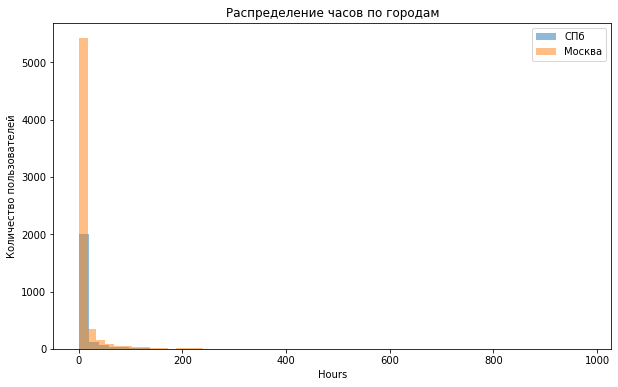

In [6]:
plt.figure(figsize=(10,6))
plt.hist(pd_users_spb['hours'], bins=50, alpha=0.5, label='СПб')
plt.hist(pd_users_msk['hours'], bins=50, alpha=0.5, label='Москва')
plt.xlabel('Hours')
plt.ylabel('Количество пользователей')
plt.title('Распределение часов по городам')
plt.legend()
plt.show()


Количество пользователей:

СПб: 2306
Москва: 6234
в Москве данных примерно в 3 раза больше.

Среднее по hours:
СПб: 11.26
Москва: 10.88
в среднем пользователи в Питере чуть дольше.

Медиана (50%) по hours:
СПб: 0.88
Москва: 0.92
вот медиана почти одинаковая, значит «средний пользователь» ведёт себя одинаково.

Разброс (std) и max:
Разброс очень большой (есть пользователи с сотнями часов)

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [7]:
from scipy.stats import ttest_ind, mannwhitneyu

hours_spb = pd_users_spb['hours']
hours_msk = pd_users_msk['hours']

t_stat, p_val = ttest_ind(hours_spb, hours_msk, equal_var=False, alternative='greater')

print("T-test:")
print("t-статистика =", t_stat)
print("p-value =", p_val)

u_stat, p_val_u = mannwhitneyu(hours_spb, hours_msk, alternative='greater')

print("\nMann–Whitney U test:")
print("U-статистика =", u_stat)
print("p-value =", p_val_u)

T-test:
t-статистика = 0.4027674917811479
p-value = 0.3435708118766314

Mann–Whitney U test:
U-статистика = 7157178.5
p-value = 0.6189600878052618


## 3. Аналитическая записка

Выбранный тест и уровень значимости
Для проверки гипотезы использовался двухвыборочный t-test для независимых выборок (односторонний, так как предполагалось, что пользователи Санкт-Петербурга более активны, чем пользователи Москвы). Уровень статистической значимости был принят равным α = 0.05. Для проверки устойчивости результатов дополнительно применён непараметрический тест Манна–Уитни.

Результаты тестов

T-test: t-статистика = 0.40, p-value = 0.34
Mann–Whitney U test: U-статистика = 7 157 178.5, p-value = 0.62

Интерпретация
Значения p-value существенно превышают уровень значимости (0.05). Это означает, что у нас нет оснований отвергать нулевую гипотезу. Средняя активность пользователей Москвы и Санкт-Петербурга в приложении статистически значимо не отличается.

Возможные причины полученных результатов
Пользователи из Москвы и Санкт-Петербурга обладают схожими паттернами поведения: близкий уровень дохода, культурные привычки и доступность сервисов. Размер выборки достаточен для выявления сильных различий, однако разница в реальности действительно мала и несущественна с практической точки зрения.